# SECTION 1: Environment Verification\nWe verify Python version, TensorFlow version, TFRS version, GPU, and RAM.

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import sys
import psutil
import tensorflow as tf
import tensorflow_recommenders as tfrs

print(f"Python Version: {sys.version}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"TensorFlow Recommenders Version: {tfrs.__version__}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Detection: {len(gpus)} GPU(s) found.")
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("GPU Detection: No GPU found, using CPU.")

ram = psutil.virtual_memory()
print(f"System RAM: {ram.total / (1024**3):.2f} GB total, {ram.available / (1024**3):.2f} GB available")

c:\Users\rudra\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.4) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)



Python Version: 3.10.4 (tags/v3.10.4:9d38120, Mar 23 2022, 23:13:41) [MSC v.1929 64 bit (AMD64)]
TensorFlow Version: 2.18.0
TensorFlow Recommenders Version: v0.7.7
GPU Detection: No GPU found, using CPU.
System RAM: 11.71 GB total, 1.36 GB available


# SECTION 2: Load Data\nLoad the `processed_interactions.csv` and `processed_products.csv` files.

In [2]:
import pandas as pd
import os

interactions_path = 'processed_interactions.csv'
products_path = 'processed_products.csv'

if os.path.exists(interactions_path) and os.path.exists(products_path):
    interactions_df = pd.read_csv(interactions_path)
    products_df = pd.read_csv(products_path)
    print("Data loaded successfully from CSVs!")
else:
    print("Error: CSV files not found. Attempting to fetch directly from PostgreSQL as fallback...")
    import psycopg2
    from dotenv import load_dotenv
    env_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '.env'))
    load_dotenv(dotenv_path=env_path)
    
    conn = psycopg2.connect(
        host=os.getenv("DB_HOST", "localhost"),
        database=os.getenv("DB_NAME", "mydb"),
        user=os.getenv("DB_USER", "postgres"),
        password=os.getenv("DB_PASSWORD", "Rudra@005")
    )
    
    products_query = "SELECT id, name, category, price, description FROM shop_product;"
    interactions_query = "SELECT user_id, product_id, interaction_type AS event_type, created_at AS timestamp FROM shop_userinteraction;"
    
    products_df = pd.read_sql_query(products_query, conn)
    interactions_df = pd.read_sql_query(interactions_query, conn)
    print("Data loaded successfully from PostgreSQL!")

Error: CSV files not found. Attempting to fetch directly from PostgreSQL as fallback...


C:\Users\rudra\AppData\Local\Temp\ipykernel_47168\2799338371.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products_df = pd.read_sql_query(products_query, conn)
C:\Users\rudra\AppData\Local\Temp\ipykernel_47168\2799338371.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  interactions_df = pd.read_sql_query(interactions_query, conn)


Data loaded successfully from PostgreSQL!


# SECTION 3: Dataset Overview\nDisplay basic counts for Users, Products, Interactions, and Unique User-Product Pairs.

In [3]:
num_users = interactions_df['user_id'].nunique()
num_products = products_df['id'].nunique()
num_interactions = len(interactions_df)
num_unique_pairs = interactions_df.groupby(['user_id', 'product_id']).ngroups

print("=== DATASET OVERVIEW ===")
print(f"Number of Users: {num_users}")
print(f"Number of Products: {num_products}")
print(f"Number of Interactions: {num_interactions}")
print(f"Number of Unique User-Product Pairs: {num_unique_pairs}")

=== DATASET OVERVIEW ===
Number of Users: 1002
Number of Products: 600
Number of Interactions: 113459
Number of Unique User-Product Pairs: 62676


# SECTION 4: Data Quality Checks\nCheck for missing values, duplicate rows, and invalid IDs.

In [4]:
print("=== DATA QUALITY CHECKS ===")

# Missing Values
print("\nMissing Values in Interactions:")
print(interactions_df.isnull().sum())
print("\nMissing Values in Products:")
print(products_df.isnull().sum())

# Duplicates
print(f"\nDuplicate rows in Interactions: {interactions_df.duplicated().sum()}")
print(f"Duplicate rows in Products: {products_df.duplicated().sum()}")

# Invalid IDs
invalid_product_ids = interactions_df[~interactions_df['product_id'].isin(products_df['id'])]
print(f"\nInteractions with Invalid Product IDs: {len(invalid_product_ids)}")

if len(invalid_product_ids) == 0:
    print("All interaction product IDs are valid.")

=== DATA QUALITY CHECKS ===

Missing Values in Interactions:
user_id       0
product_id    0
event_type    0
timestamp     0
dtype: int64

Missing Values in Products:
id             0
name           0
category       0
price          0
description    0
dtype: int64

Duplicate rows in Interactions: 0
Duplicate rows in Products: 0

Interactions with Invalid Product IDs: 0
All interaction product IDs are valid.


# SECTION 5: Interaction Analysis\nCalculate Average Interactions Per User, Per Product, Most Active Users, and Most Popular Products.

In [5]:
avg_interactions_per_user = num_interactions / num_users if num_users > 0 else 0
avg_interactions_per_product = num_interactions / num_products if num_products > 0 else 0

print("=== INTERACTION ANALYSIS ===")
print(f"Average Interactions Per User: {avg_interactions_per_user:.2f}")
print(f"Average Interactions Per Product: {avg_interactions_per_product:.2f}")

print("\nTop 5 Most Active Users (by interaction count):")
print(interactions_df['user_id'].value_counts().head(5))

print("\nTop 5 Most Popular Products (by interaction count):")
top_product_ids = interactions_df['product_id'].value_counts().head(5)
for pid, count in top_product_ids.items():
    p_name = products_df[products_df['id'] == pid]['name'].values[0]
    print(f"Product ID {pid} ({p_name}): {count} interactions")

=== INTERACTION ANALYSIS ===
Average Interactions Per User: 113.23
Average Interactions Per Product: 189.10

Top 5 Most Active Users (by interaction count):
user_id
3      13003
1      12859
553      154
265      151
196      151
Name: count, dtype: int64

Top 5 Most Popular Products (by interaction count):
Product ID 158 (Bose Bluetooth Headphones RGB): 380 interactions
Product ID 138 (JBL Noise Cancelling Headphones Premium): 370 interactions
Product ID 129 (Bose Noise Cancelling Headphones Premium): 364 interactions
Product ID 174 (Noise Wireless Headphones ANC): 362 interactions
Product ID 132 (Noise Bluetooth Headphones ANC): 361 interactions


# SECTION 6: Interaction Sparsity\nCalculate the sparsity of the user-product recommendation matrix.

In [6]:
# Sparsity = 1 - (Unique Interactions / (Total Users * Total Products))
possible_interactions = num_users * num_products
sparsity = 1 - (num_unique_pairs / possible_interactions) if possible_interactions > 0 else 1

print("=== INTERACTION SPARSITY ===")
print(f"Possible User-Product Pairs: {possible_interactions}")
print(f"Actual Unique User-Product Pairs: {num_unique_pairs}")
print(f"Recommendation Matrix Sparsity: {sparsity:.4%} ({(sparsity*100):.4f}%)")

=== INTERACTION SPARSITY ===
Possible User-Product Pairs: 601200
Actual Unique User-Product Pairs: 62676
Recommendation Matrix Sparsity: 89.5749% (89.5749%)


# SECTION 7: Event Distribution Analysis\nVisualize the distribution of event types: view, wishlist, cart, purchase.

C:\Users\rudra\AppData\Local\Temp\ipykernel_47168\3895047264.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=interactions_df, x='event_type', order=['view', 'wishlist', 'cart', 'purchase'], palette='viridis')


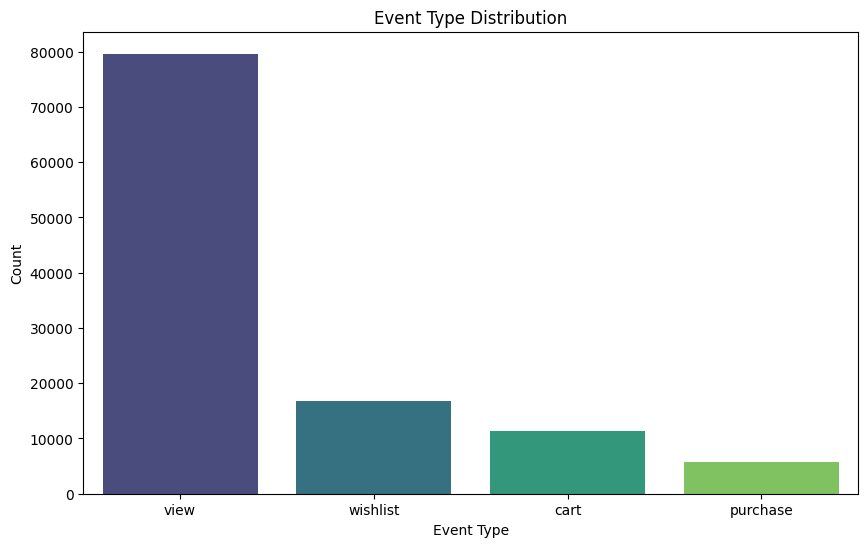


Event Counts:
event_type
view        79621
wishlist    16835
cart        11353
purchase     5650
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=interactions_df, x='event_type', order=['view', 'wishlist', 'cart', 'purchase'], palette='viridis')
plt.title('Event Type Distribution')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.show()

print("\nEvent Counts:")
print(interactions_df['event_type'].value_counts())

# SECTION 8: User Activity Analysis\nGenerate histograms and boxplots for user activity levels.

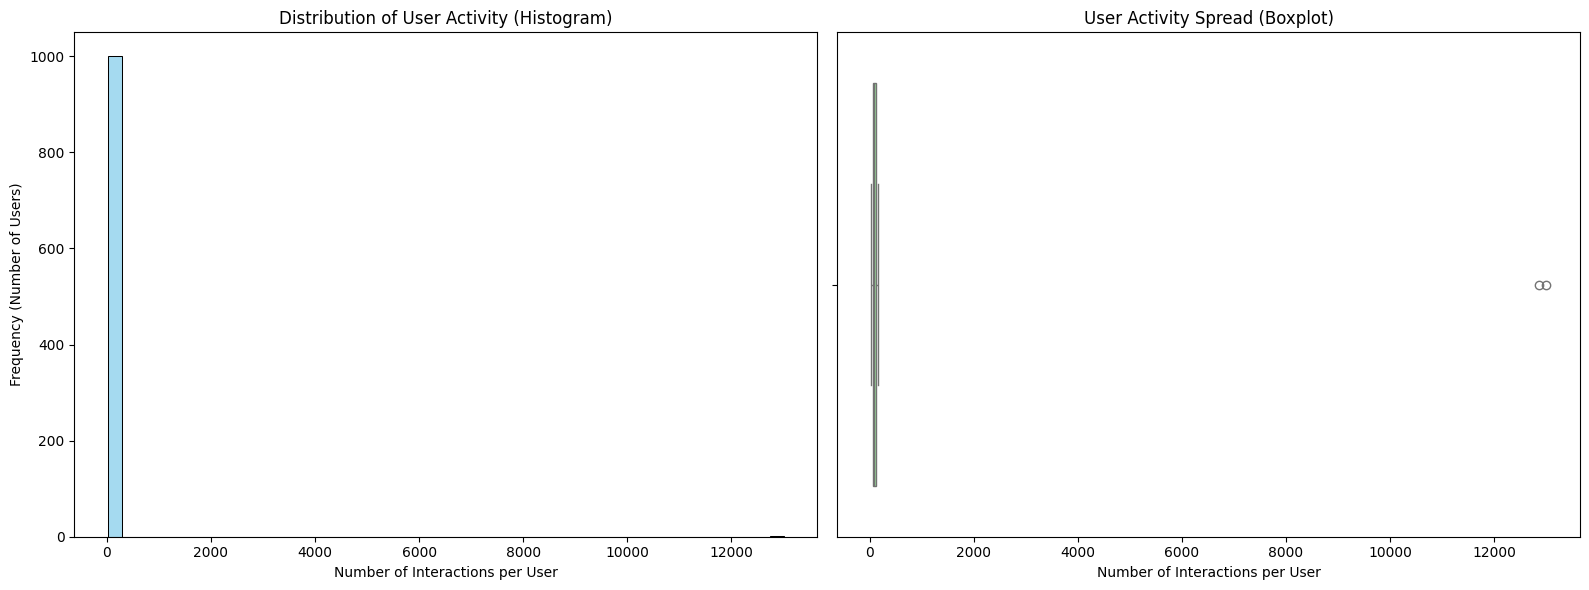

User Activity Stats:
count     1002.000000
mean       113.232535
std        574.508250
min         24.000000
25%         58.000000
50%         90.000000
75%        116.000000
max      13003.000000
dtype: float64


In [8]:
user_activity = interactions_df.groupby('user_id').size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(user_activity, bins=50, ax=ax1, color='skyblue')
ax1.set_title('Distribution of User Activity (Histogram)')
ax1.set_xlabel('Number of Interactions per User')
ax1.set_ylabel('Frequency (Number of Users)')

# Boxplot
sns.boxplot(x=user_activity, ax=ax2, color='lightgreen')
ax2.set_title('User Activity Spread (Boxplot)')
ax2.set_xlabel('Number of Interactions per User')

plt.tight_layout()
plt.show()

print("User Activity Stats:")
print(user_activity.describe())

# SECTION 9: Product Popularity Analysis\nGenerate visualizations for top products and long tail distribution.

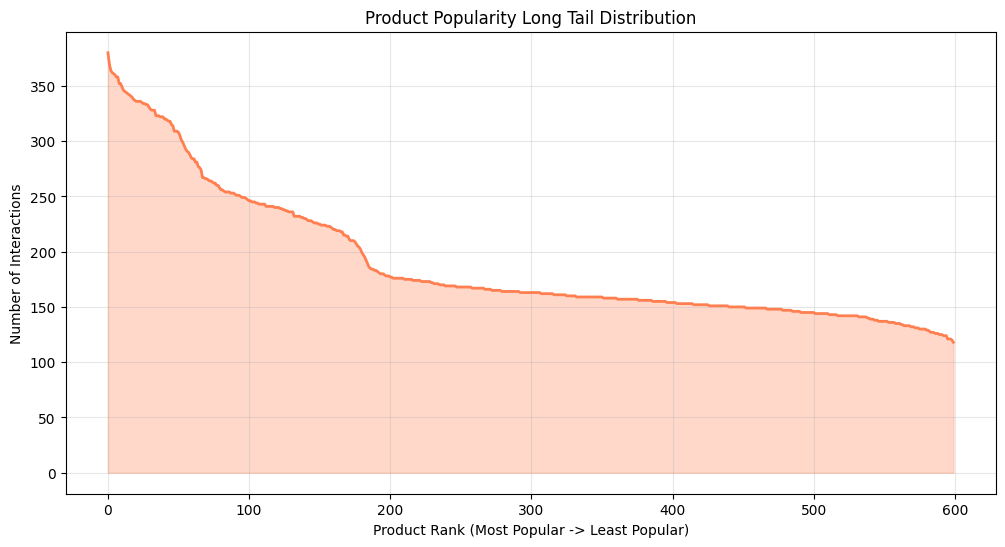

Top 10 Products Summary:
product_id
158    380
138    370
129    364
174    362
132    361
139    360
149    358
169    358
160    352
137    352
dtype: int64


In [9]:
product_popularity = interactions_df.groupby('product_id').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.plot(range(len(product_popularity)), product_popularity.values, color='coral', linewidth=2)
plt.fill_between(range(len(product_popularity)), product_popularity.values, color='coral', alpha=0.3)
plt.title('Product Popularity Long Tail Distribution')
plt.xlabel('Product Rank (Most Popular -> Least Popular)')
plt.ylabel('Number of Interactions')
plt.grid(True, alpha=0.3)
plt.show()

print("Top 10 Products Summary:")
print(product_popularity.head(10))

# SECTION 10: Feature Engineering\nMap Event Weights and create `weighted_interaction_score`.

In [10]:
event_weights = {
    'view': 1,
    'wishlist': 3,
    'cart': 4,
    'purchase': 5
}

interactions_df['weighted_interaction_score'] = interactions_df['event_type'].map(event_weights)

print("=== FEATURE ENGINEERING ===")
print("Mapped Event Weights:")
print(interactions_df[['event_type', 'weighted_interaction_score']].head(10))

# Aggregate to get a final score per user-product pair (using max score)
user_item_matrix = interactions_df.groupby(['user_id', 'product_id'])['weighted_interaction_score'].max().reset_index()
print(f"\nAggregated User-Item Matrix shape: {user_item_matrix.shape}")
print(user_item_matrix.head())

=== FEATURE ENGINEERING ===
Mapped Event Weights:
  event_type  weighted_interaction_score
0       view                           1
1       view                           1
2       view                           1
3       cart                           4
4   purchase                           5
5       view                           1
6       view                           1
7   wishlist                           3
8       view                           1
9       view                           1

Aggregated User-Item Matrix shape: (62676, 3)
   user_id  product_id  weighted_interaction_score
0        1           2                           5
1        1           3                           5
2        1           4                           5
3        1           5                           5
4        1           6                           5


# SECTION 11: Dataset Export\nSave processed data for the training pipeline.

In [11]:
interactions_df.to_csv('processed_interactions.csv', index=False)
products_df.to_csv('processed_products.csv', index=False)

print("=== DATASET EXPORT ===")
print("Saved 'processed_interactions.csv'")
print("Saved 'processed_products.csv'")

=== DATASET EXPORT ===
Saved 'processed_interactions.csv'
Saved 'processed_products.csv'


# SECTION 12: Recommendation Readiness Report\nGenerate summary tables and insights.

In [12]:
import numpy as np

readiness_checks = []
if num_users >= 1000:
    readiness_checks.append("✅ Users count is adequate (>= 1000).")
else:
    readiness_checks.append("⚠️ Users count is low for deep learning (< 1000).")
    
if num_interactions >= 50000:
    readiness_checks.append("✅ Interactions count is adequate (>= 50000).")
else:
    readiness_checks.append("⚠️ Interactions count is low for deep learning (< 50000).")

if sparsity < 0.999:
    readiness_checks.append(f"✅ Sparsity is excellent for DL ({sparsity*100:.2f}%).")
else:
    readiness_checks.append(f"⚠️ Matrix is highly sparse ({sparsity*100:.2f}%).")

print("=========================================")
print("   RECOMMENDATION READINESS REPORT")
print("=========================================")
for check in readiness_checks:
    print(check)

print("\n--- Dataset Final Summary ---")
summary_df = pd.DataFrame({
    'Metric': ['Total Users', 'Total Products', 'Total Interactions', 'Sparsity', 'Avg Interactions/User'],
    'Value': [num_users, num_products, num_interactions, f"{sparsity*100:.2f}%", f"{avg_interactions_per_user:.2f}"]
})
print(summary_df.to_string(index=False))
print("=========================================")

   RECOMMENDATION READINESS REPORT
✅ Users count is adequate (>= 1000).
✅ Interactions count is adequate (>= 50000).
✅ Sparsity is excellent for DL (89.57%).

--- Dataset Final Summary ---
               Metric  Value
          Total Users   1002
       Total Products    600
   Total Interactions 113459
             Sparsity 89.57%
Avg Interactions/User 113.23


In [13]:
interactions_df['user_id'].value_counts().head(10)

user_id
3      13003
1      12859
553      154
265      151
196      151
174      151
554      149
834      149
668      148
880      148
Name: count, dtype: int64

In [14]:
train_interactions_df = interactions_df[
    ~interactions_df['user_id'].isin([1, 3])
].copy()

print("Users:", train_interactions_df['user_id'].nunique())
print("Interactions:", len(train_interactions_df))

Users: 1000
Interactions: 87597


In [15]:
train_interactions_df['user_id'].value_counts().describe()

count    1000.000000
mean       87.597000
std        33.660773
min        24.000000
25%        58.000000
50%        90.000000
75%       116.000000
max       154.000000
Name: count, dtype: float64

In [16]:
# Remove outlier users from training dataset
train_interactions_df = interactions_df[
    ~interactions_df['user_id'].isin([1, 3])
].copy()

print("Original Users:", interactions_df['user_id'].nunique())
print("New Users:", train_interactions_df['user_id'].nunique())

print("Original Interactions:", len(interactions_df))
print("New Interactions:", len(train_interactions_df))

Original Users: 1002
New Users: 1000
Original Interactions: 113459
New Interactions: 87597
